# Python Script for Educational AI

In [6]:
#Import necesary modules to run the code
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
# import numdifftools as nd
   
from matplotlib import rc
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

import math
import scipy
from scipy import integrate
from scipy import optimize
from scipy.misc import derivative
from scipy.optimize import fsolve

# from sympy import *  #check 
from sympy import exp, Symbol, nsolve

from numpy import sqrt, sin, cos, pi
import csv
import time

In [11]:
# pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


# Human-prepared Data

In [8]:
# Converting excel(.xlsx) file to more readable csv file
# Python Conversion Script
# You will need to install the openpyxl engine first: pip install pandas openpyxl.

import pandas as pd

# 1. Load the Excel file (.xlsx or .xls)
# Change 'input_file.xlsx' to your actual file name
# excel_data = pd.read_excel('input_file.xlsx')
excel_data = pd.read_excel(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\Alignment_Chapters_Sievert.xlsx")

# 2. Clean/Format (Optional)
# This removes empty rows and trailing whitespace from column names
excel_data.dropna(how='all', inplace=True)
excel_data.columns = excel_data.columns.str.strip()

# 3. Save as a clean CSV
# 'index=False' prevents Python from adding a new column of numbers (0, 1, 2...)
excel_data.to_csv(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\Alignment_Chapters_Sievert_cleaned.csv", index=False, encoding='utf-8')

print("Conversion complete! Your readable CSV is ready.")

Conversion complete! Your readable CSV is ready.


In [37]:
df = pd.read_csv(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\Alignment_Chapters_Sievert_cleaned_minimal.csv")
print(df)

                                            Chapter  Lectures  Formative  \
0                                    Prerequisites        1.0          5   
1                    Ch1 Stern-Gerlach Experiments        3.5          6   
2  Ch2 Rotation of Basis States / Matrix Mechanics        5.5          5   
3                             Ch3 Angular Momentum        5.0          5   
4                               Ch4 Time Evolution        5.0          7   
5               Ch5 System of 2 Spin-1/2 Particles        2.0          3   
6                         Ch6 Wave Mechanics in 1D        4.0          3   
7                                        Extraneous       1.0          0   

   Summative  
0       0.00  
1       9.33  
2       5.97  
3       5.66  
4       3.00  
5       1.20  
6       6.83  
7       0.00  


In [43]:
#Sample workflow 

import pandas as pd
import matplotlib.pyplot as plt
 
# 1. Load the data
# Replace 'your_file.csv' with your actual filename
# df = pd.read_csv('your_file.csv')
df = pd.read_csv(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\Alignment_Chapters_Sievert_cleaned.csv")

# 2. Analyze the data
print("--- Statistical Summary ---")
print(df.describe())  # Shows mean, min, max, etc.

# Example: Calculate the mean of a specific column
# average_val = df['Column_Name'].mean()
# average_val = df['L'].mean()
# print(average_val)

# #Normalization (all)

# totL = df['Lectures'].sum()
# totF = df['Formative'].sum()
# totS = df['Summative'].sum() 

# print("total: {} Lectures, {} Formative, {} Summative".format(totL, totF, totS))


#Normalization (selected rows)

totL = df['Lectures'].iloc[1:6].sum()
totF = df['Formative'].iloc[1:6].sum()
totS = df['Summative'].iloc[1:6].sum() 

print("total: {} Lectures, {} Formative, {} Summative".format(totL, totF, totS))



# #Dot products: cosine alignment (all rows)

# L = df['L'] #Lecture
# LdotL = L * L
# totLdotL = LdotL.sum()
# print("Lectures/Lectures = {}, total Lectures/Lectures = {}".format(LdotL, totLdotL))

# F = df['F'] #Formative
# FdotF = F * F
# totFdotF = FdotF.sum()
# print("Formative/Formative = {}, total Formative/Formative = {}".format(FdotF, totFdotF))

# S = df['S'] #Summative
# SdotS = S * S
# totSdotS = SdotS.sum()
# print("Summative/Summative = {}, total Summative/Summative = {}".format(SdotS, totSdotS))


#Dot products: cosine alignment (selected rows)

L = df['L'] #Lecture
LdotL = L * L
totLdotL = LdotL.iloc[1:6].sum()
print("Lectures/Lectures = {}, total Lectures/Lectures = {}".format(LdotL, totLdotL))

F = df['F'] #Formative
FdotF = F * F
totFdotF = FdotF.iloc[1:6].sum()
print("Formative/Formative = {}, total Formative/Formative = {}".format(FdotF, totFdotF))

S = df['S'] #Summative
SdotS = S * S
totSdotS = SdotS.iloc[1:6].sum()
print("Summative/Summative = {}, total Summative/Summative = {}".format(SdotS, totSdotS))


LdotF = L * F
LdotS = L * S
FdotS = F * S


# # Sums values in rows 1 to 6 for the LdotF column (selected rows)

# totLdotF = LdotF.sum()
# totLdotS = LdotS.sum()
# totFdotS = FdotS.sum()


# Sums values in rows 1 to 6 for the LdotF column (selected rows)

totLdotF = LdotF.iloc[1:6].sum()
totLdotS = LdotS.iloc[1:6].sum()
totFdotS = FdotS.iloc[1:6].sum()



print("Lectures/Formative = {}, total Lectures/Formative = {}".format(LdotF, totLdotF))
print("Lectures/Summative = {}, total Lectures/Summative = {}".format(LdotS, totLdotS))
print("Formative/Summative = {}, total Formative/Summative = {}".format(FdotS, totFdotS))

# print("total: Lectures/Formative = {}, Lectures/Summative = {}, Formative/Summative = {}".format(totLdotF, totLdotS, totFdotS))


totalignLdotF = totLdotF / np.sqrt(totLdotL * totFdotF)
totalignLdotS = totLdotS / np.sqrt(totLdotL * totSdotS)
totalignFdotS = totFdotS / np.sqrt(totFdotF * totSdotS)

print("total alignment: Lectures/Formative = {}, Lectures/Summative = {}, Formative/Summative = {}".format(totalignLdotF, totalignLdotS, totalignFdotS))



--- Statistical Summary ---
           chp   Lectures  Formative  Summative         L         F         S
count  8.00000   9.000000   9.000000   9.000000  8.000000  8.000000  8.000000
mean   3.50000   6.000000   7.555556   7.108889  0.125000  0.125000  0.124961
std    2.44949   8.058381  10.125600   9.876409  0.067680  0.064342  0.108185
min    0.00000   1.000000   0.000000   0.000000  0.037037  0.000000  0.000000
25%    1.75000   2.000000   3.000000   1.200000  0.064815  0.088235  0.028125
50%    3.50000   4.000000   5.000000   5.660000  0.138889  0.147059  0.135313
75%    5.25000   5.000000   6.000000   6.830000  0.185185  0.154412  0.193281
max    7.00000  27.000000  34.000000  31.990000  0.203704  0.205882  0.291563
total: 21.0 Lectures, 26 Formative, 25.16 Summative
Lectures/Lectures = 0    0.001372
1    0.016804
2    0.041495
3    0.034294
4    0.034294
5    0.005487
6    0.021948
7    0.001372
8         NaN
Name: L, dtype: float64, total Lectures/Lectures = 0.13237311385459524
F

In [ ]:
#Plot data from Excel (.csv) file
#Sievert_2024 

# # 3. Plot the data
# plt.figure(figsize=(10, 6))

# # Example: A simple line plot
# # Replace 'X_Axis_Column' and 'Y_Axis_Column' with your actual headers
# plt.plot(df['X_Axis_Column'], df['Y_Axis_Column'], marker='o', linestyle='-', color='b', label='Data Trend')

# # Customizing the chart
# plt.title('Data Analysis Results')
# plt.xlabel('X-Axis Label')
# plt.ylabel('Y-Axis Label')
# plt.legend()
# plt.grid(True)

# # Display the plot
# plt.show()


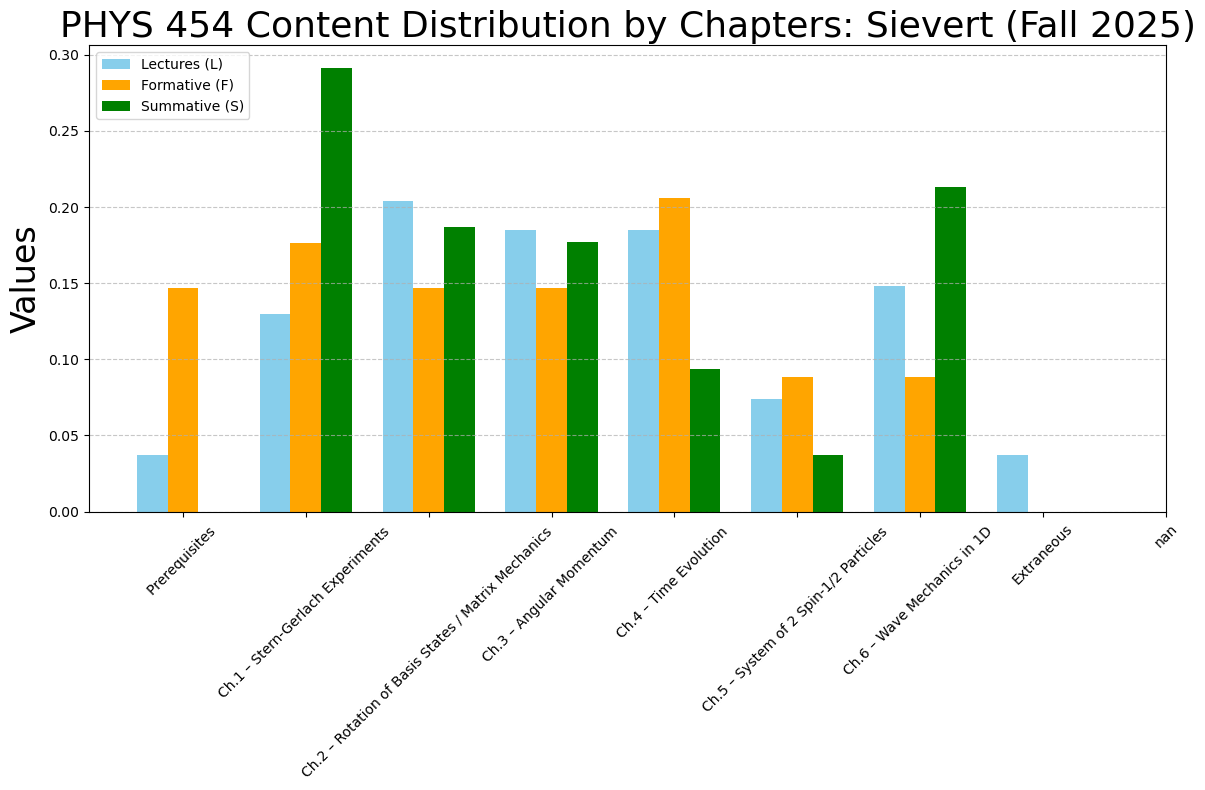

In [45]:
import matplotlib.pyplot as plt
import numpy as np

#PlotA: Content distribution by chapter (2D column plot): all rows


# 1. Setup data (all data)
chapters = df['name'] # Or df.index if chapters aren't a column
x = np.arange(len(chapters))  # Label locations
width = 0.25  # Width of the bars

# # 1. Slice your data to match your analysis (Rows 1 to 5)
# # Using 1:6 to match your .iloc[1:6] logic from the previous step
# subset_df = df.iloc[1:6] 
# chapters = subset_df['name'] # Ensure 'Chapter' is the name of your column
# x = np.arange(len(chapters))     # Create index positions (0, 1, 2...)
# width = 0.25 

# 2. Create the plot
fig, ax = plt.subplots(figsize=(12, 8))


# Offset each category by the width so they stand side-by-side
rects1 = ax.bar(x - width, df['L'], width, label='Lectures (L)', color='skyblue')
rects2 = ax.bar(x, df['F'], width, label='Formative (F)', color='orange')
rects3 = ax.bar(x + width, df['S'], width, label='Summative (S)', color='green')

# 3. Add labels and formatting
# ax.set_xlabel('Chapters', fontsize=24)
ax.set_ylabel('Values', fontsize=24)
ax.set_title('PHYS 454 Content Distribution by Chapters: Sievert (Fall 2025)', fontsize=26)
ax.set_xticks(x)
ax.set_xticklabels(chapters, rotation=45)
ax.legend()

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# plt.savefig(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\content_dist_by_chapters_Sievert_2025_ch1to6.png", bbox_inches='tight')
# plt.savefig(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\content_dist_by_chapters_Sievert_2025_all.png", bbox_inches='tight')
plt.show()


total alignment: Lectures/Formative = 0.971316092723073, Lectures/Summative = 0.8807294874624869, Formative/Summative = 0.8995588974919235


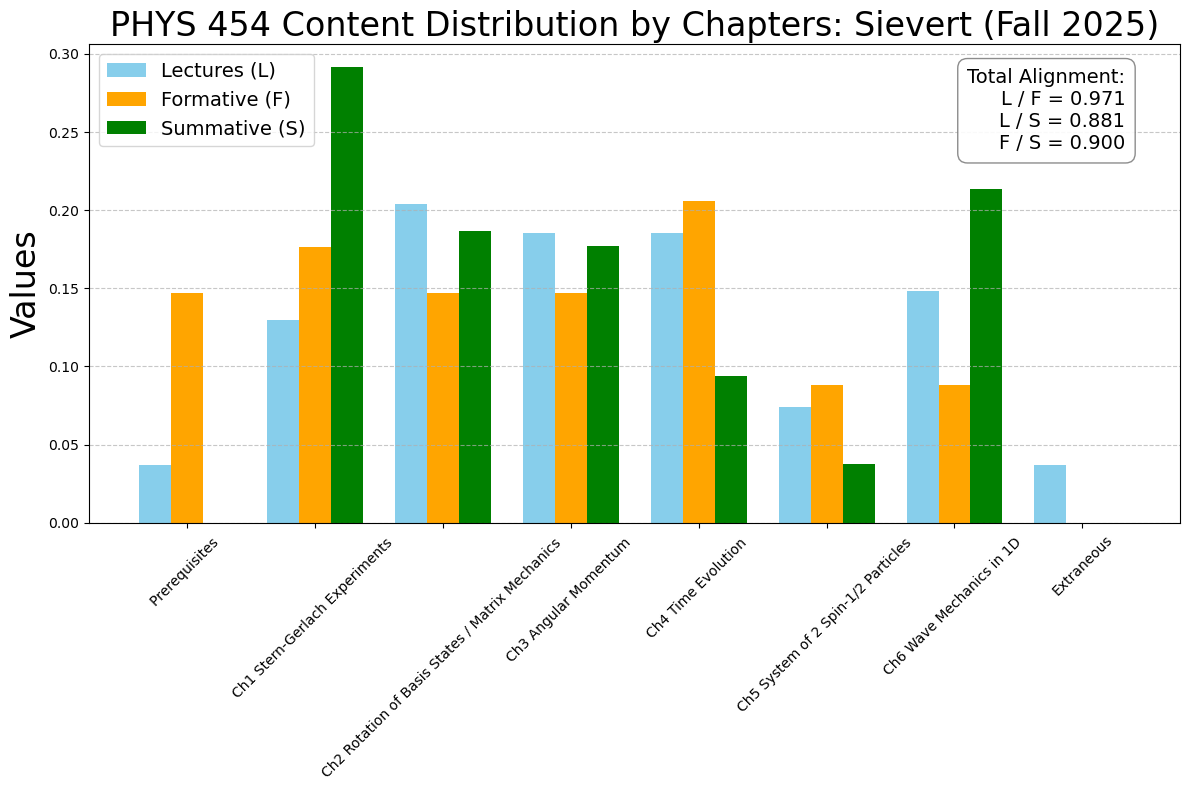

In [76]:
#Same plot as above with added textbox of alignment of vectors
import matplotlib.pyplot as plt
import numpy as np

# --- MATH CALCULATIONS ---
# (Ensure these dot product variables are computed from your data before this script runs)
totalignLdotF = totLdotF / np.sqrt(totLdotL * totFdotF)
totalignLdotS = totLdotS / np.sqrt(totLdotL * totSdotS)
totalignFdotS = totFdotS / np.sqrt(totFdotF * totSdotS)

print("total alignment: Lectures/Formative = {}, Lectures/Summative = {}, Formative/Summative = {}".format(totalignLdotF, totalignLdotS, totalignFdotS))

# --- PLOTTING CODE ---
# PlotA: Content distribution by chapter (2D column plot): all rows

# 1. Setup data (all data)
chapters = df['name'] 
x = np.arange(len(chapters))  
width = 0.25  

# 2. Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Offset each category by the width so they stand side-by-side
rects1 = ax.bar(x - width, df['L'], width, label='Lectures (L)', color='skyblue')
rects2 = ax.bar(x, df['F'], width, label='Formative (F)', color='orange')
rects3 = ax.bar(x + width, df['S'], width, label='Summative (S)', color='green')

# 3. Add labels and formatting
ax.set_ylabel('Values', fontsize=24)
ax.set_title('PHYS 454 Content Distribution by Chapters: Sievert (Fall 2025)', fontsize=24)
ax.set_xticks(x)
ax.set_xticklabels(chapters, rotation=45)
ax.legend(loc='upper left', fontsize=14) # Fixed legend to upper left to save space

# --- ADDED: MATHEMATICAL ALIGNMENT TEXT BOX ---
# Format the metrics text cleanly with rounding to 3 decimal places
alignment_text = (
    f"Total Alignment:\n"
    f"L / F = {totalignLdotF:.3f}\n"
    f"L / S = {totalignLdotS:.3f}\n"
    f"F / S = {totalignFdotS:.3f}"
)

# Place the text box in the upper right quadrant of the chart area
ax.text(
    0.95, 0.95, alignment_text, 
    transform=ax.transAxes, 
    fontsize=14,
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
)

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# plt.savefig(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\content_dist_by_chapters_Sievert_2025_ch1to6.png", bbox_inches='tight')
# plt.savefig(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\content_dist_by_chapters_Sievert_2025_all.png", bbox_inches='tight')
plt.show()


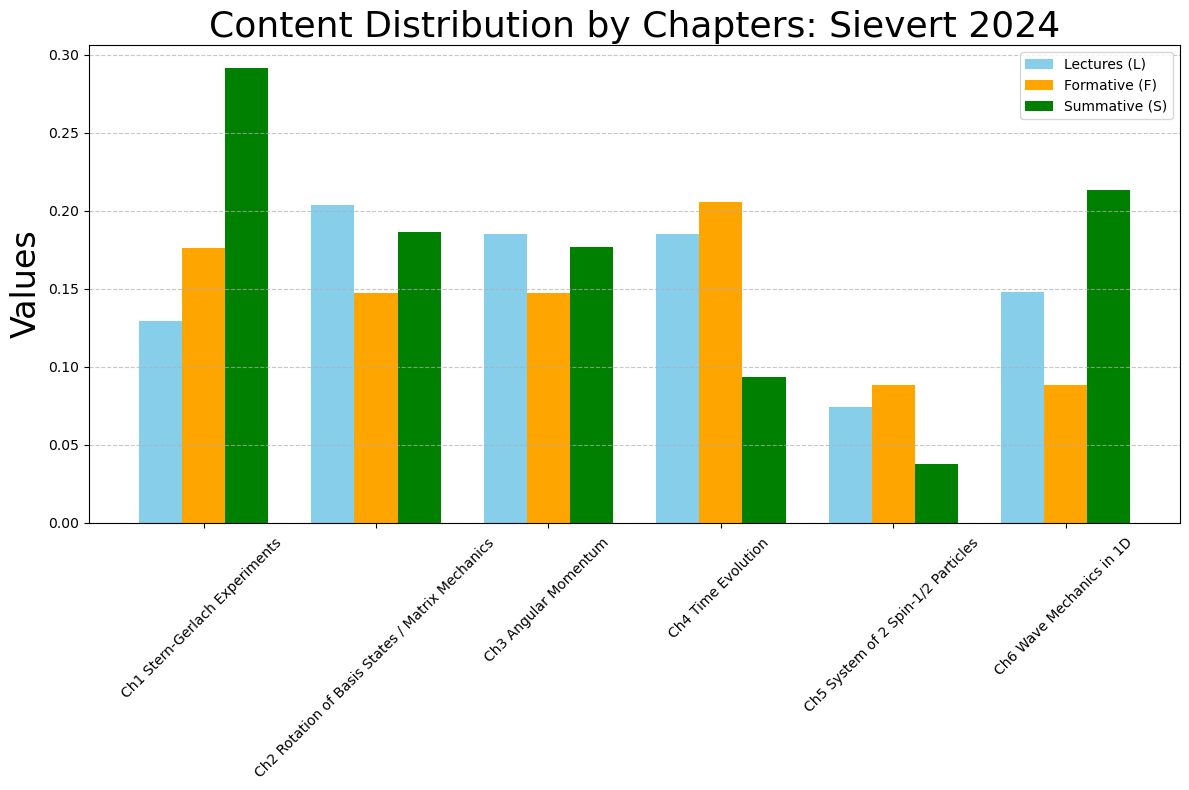

In [101]:
# 1. Select the rows first so everything is the same size (5 rows)
subset_df = df.iloc[1:7] 
chapters = subset_df['name']

# 2. Create 'x' based on the 5 rows in the subset
x = np.arange(len(subset_df)) 
width = 0.25

fig, ax = plt.subplots(figsize=(12, 8))

# 3. Plot using ONLY the subset data
# Use subset_df instead of the original df
ax.bar(x - width, subset_df['L'], width, label='Lectures (L)', color='skyblue')
ax.bar(x,         subset_df['F'], width, label='Formative (F)', color='orange')
ax.bar(x + width, subset_df['S'], width, label='Summative (S)', color='green')

# 4. Set the labels using the subset chapter names
# Add labels and formatting
# ax.set_xlabel('Chapters', fontsize=24)
ax.set_ylabel('Values', fontsize=24)
ax.set_title('PHYS 454 Content Distribution by Chapters: Sievert (Fall 2025)', fontsize=26)
ax.set_xticks(x)
ax.set_xticklabels(chapters, rotation=45)
ax.legend()

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# plt.savefig(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\content_dist_by_chapters_Sievert_2025_ch1to6.png", bbox_inches='tight')
plt.show()


total alignment: Lectures/Formative = 0.971316092723073, Lectures/Summative = 0.8807294874624869, Formative/Summative = 0.8995588974919235


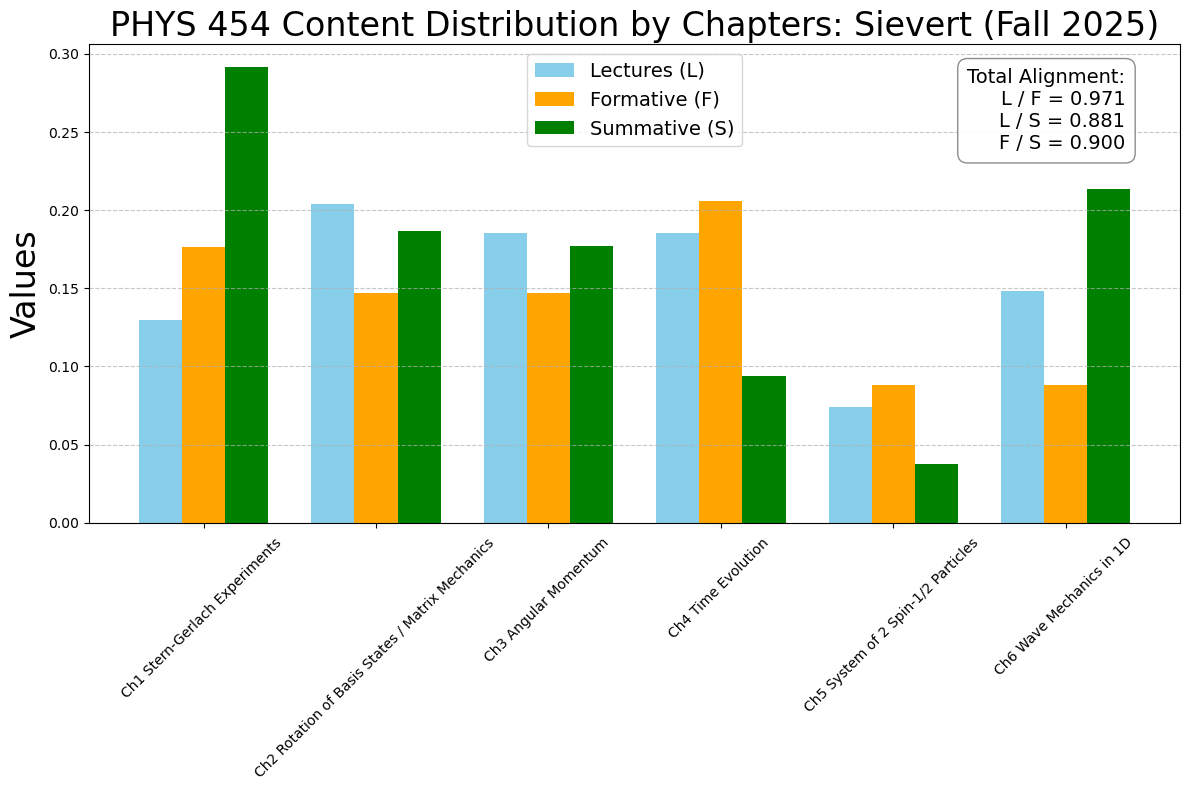

In [82]:
#Same plot as above with added textbox of alignment of vectors
import matplotlib.pyplot as plt
import numpy as np

# --- MATH CALCULATIONS ---
# (Ensure these dot product variables are computed from your data before this script runs)
totalignLdotF = totLdotF / np.sqrt(totLdotL * totFdotF)
totalignLdotS = totLdotS / np.sqrt(totLdotL * totSdotS)
totalignFdotS = totFdotS / np.sqrt(totFdotF * totSdotS)

print("total alignment: Lectures/Formative = {}, Lectures/Summative = {}, Formative/Summative = {}".format(totalignLdotF, totalignLdotS, totalignFdotS))

# --- PLOTTING CODE ---
# 1. Select the rows first so everything is the same size (6 rows)
subset_df = df.iloc[1:7] 
chapters = subset_df['name']

# 2. Create 'x' based on the rows in the subset
x = np.arange(len(subset_df)) 
width = 0.25

fig, ax = plt.subplots(figsize=(12, 8))

# 3. Plot using ONLY the subset data
ax.bar(x - width, subset_df['L'], width, label='Lectures (L)', color='skyblue')
ax.bar(x,         subset_df['F'], width, label='Formative (F)', color='orange')
ax.bar(x + width, subset_df['S'], width, label='Summative (S)', color='green')

# 4. Set the labels using the subset chapter names
ax.set_ylabel('Values', fontsize=24)
ax.set_title('PHYS 454 Content Distribution by Chapters: Sievert (Fall 2025)', fontsize=24)
ax.set_xticks(x)
ax.set_xticklabels(chapters, rotation=45)
ax.legend(loc='upper center', fontsize=14) # Moved to top-left to avoid blocking the right text box

# --- ADDED: MATHEMATICAL ALIGNMENT TEXT BOX ---
alignment_text = (
    f"Total Alignment:\n"
    f"L / F = {totalignLdotF:.3f}\n"
    f"L / S = {totalignLdotS:.3f}\n"
    f"F / S = {totalignFdotS:.3f}"
)

# Place the text box in the upper right corner of the chart
ax.text(
    0.95, 0.95, alignment_text, 
    transform=ax.transAxes, 
    fontsize=14,
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
)

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\content_dist_by_chapters_Sievert_2025_ch1to6.png", bbox_inches='tight')
plt.show()


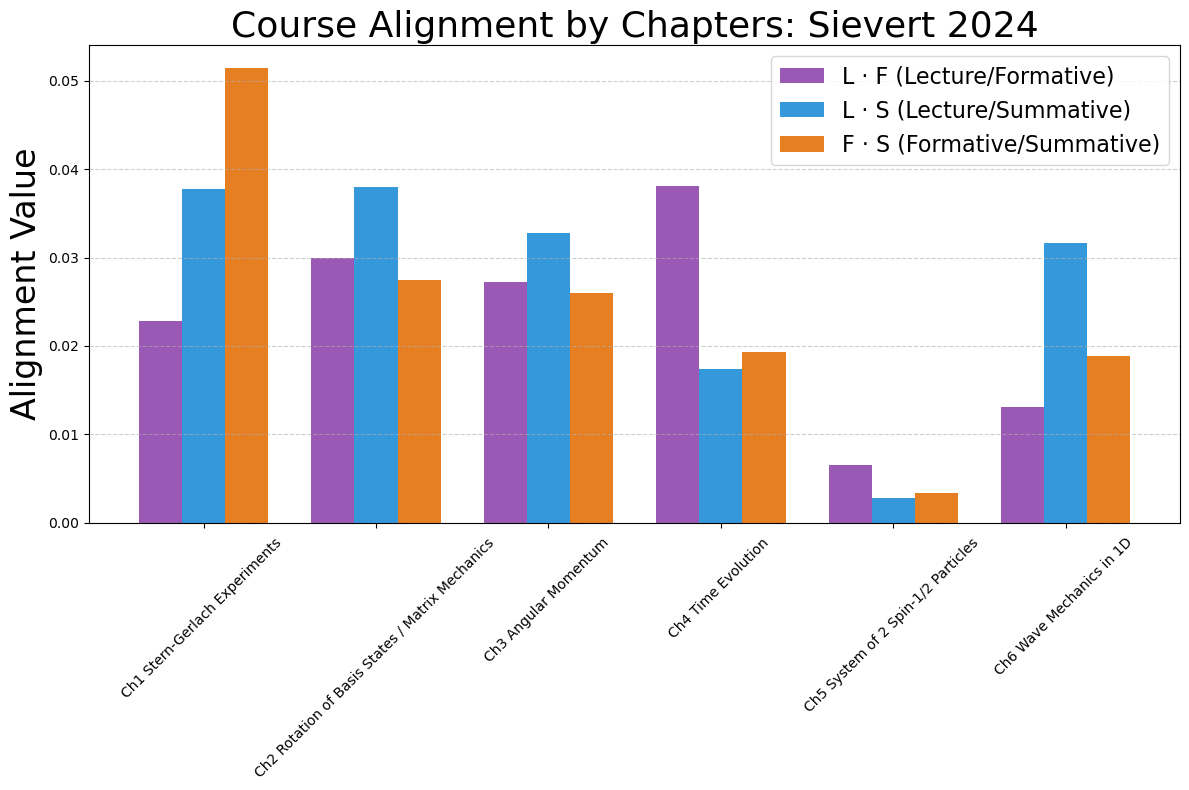

In [115]:
#Plot B: Course Alignment by Chapter: Sievert

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Slice the 6 chapters without pre and extra (Index 1 to 7)
subset = df.iloc[1:7].copy()

# 2. Calculate the dot products per chapter
subset['LdotF'] = subset['Lectures'] * subset['F']
subset['LdotS'] = subset['L'] * subset['S']
subset['FdotS'] = subset['F'] * subset['S']

# 3. Setup the plot positions
x = np.arange(len(subset))  # Length is 6
width = 0.25 

fig, ax = plt.subplots(figsize=(12, 8))

# 4. Plot the 3 dot product categories
rects1 = ax.bar(x - width, subset['LdotF'], width, label='L · F (Lecture/Formative)', color='#9b59b6') # Purple
rects2 = ax.bar(x,         subset['LdotS'], width, label='L · S (Lecture/Summative)', color='#3498db') # Blue
rects3 = ax.bar(x + width, subset['FdotS'], width, label='F · S (Formative/Summative)', color='#e67e22') # Orange

# 5. Formatting
# ax.set_xlabel('Chapters')
ax.set_ylabel('Alignment Value', fontsize=24)
ax.set_title('Course Alignment by Chapters: Sievert 2024', fontsize=26)
ax.set_xticks(x)
ax.set_xticklabels(subset['name'], rotation=45)
ax.legend(fontsize=16)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

# Save the plot (using double quotes for the path with an apostrophe)
# save_path = r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\course_alignment_by_chapters_Sievert_2024_ch1to6.png.png"
plt.savefig(save_path, bbox_inches='tight')

plt.show()


# AI-prepared Data from PDF contents

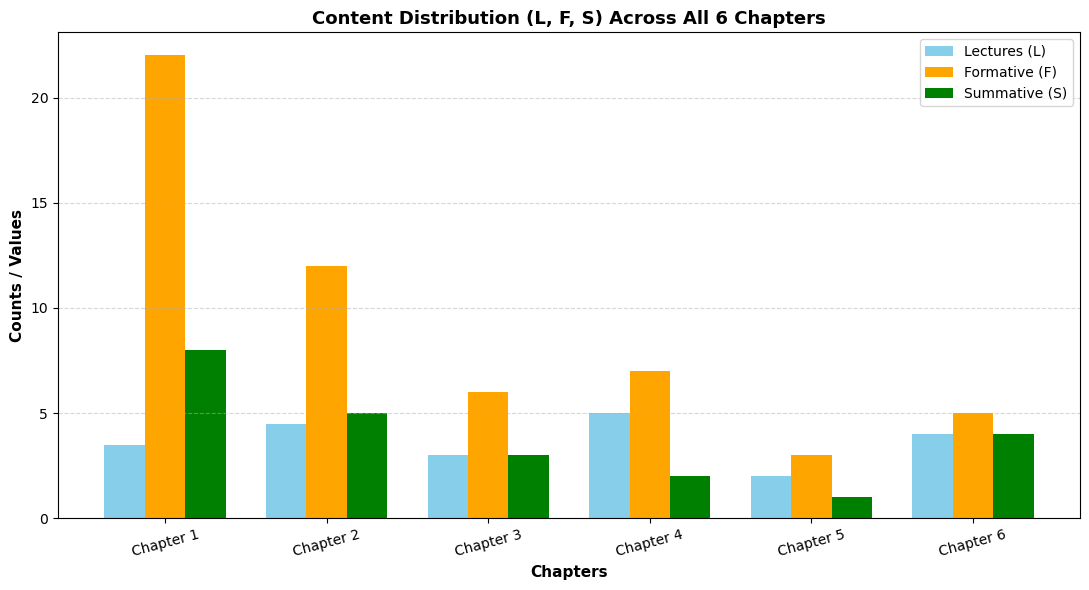

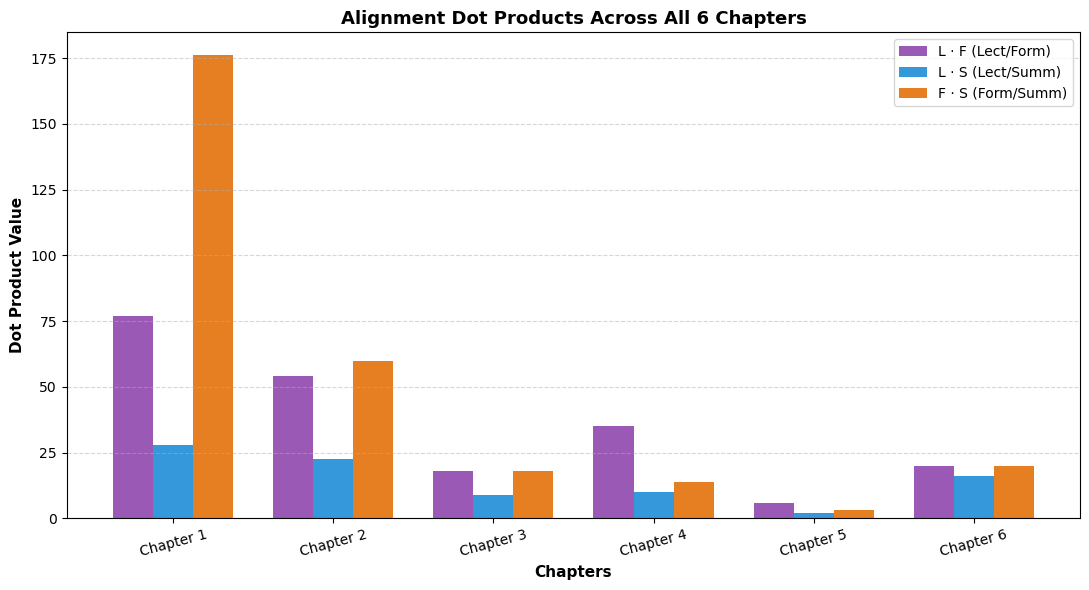

In [118]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load data directly into dataframe
csv_data = """Chapter,L,F,S
Chapter 1,3.5,22,8
Chapter 2,4.5,12,5
Chapter 3,3.0,6,3
Chapter 4,5.0,7,2
Chapter 5,2.0,3,1
Chapter 6,4.0,5,4"""

df = pd.read_csv(io.StringIO(csv_data))

# -------------------------------------------------------------
# PLOT 1: Grouped Column Plot for Raw Content Metrics (L, F, S)
# -------------------------------------------------------------
chapters = df["Chapter"]
x = np.arange(len(chapters))
width = 0.25

fig1, ax1 = plt.subplots(figsize=(11, 6))
ax1.bar(x - width, df["L"], width, label="Lectures (L)", color="skyblue")
ax1.bar(x, df["F"], width, label="Formative (F)", color="orange")
ax1.bar(x + width, df["S"], width, label="Summative (S)", color="green")

ax1.set_xlabel("Chapters", fontsize=11, fontweight="bold")
ax1.set_ylabel("Counts / Values", fontsize=11, fontweight="bold")
ax1.set_title("Content Distribution (L, F, S) Across All 6 Chapters", fontsize=13, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(chapters, rotation=15)
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
# Replace with double-quoted path if saving locally: plt.savefig(r"...", bbox_inches='tight')
plt.show()

# -------------------------------------------------------------
# PLOT 2: Grouped Column Plot for Alignment Dot Products
# -------------------------------------------------------------
# Calculate row-wise dot products matching your logic
df["LdotF"] = df["L"] * df["F"]
df["LdotS"] = df["L"] * df["S"]
df["FdotS"] = df["F"] * df["S"]

fig2, ax2 = plt.subplots(figsize=(11, 6))
ax2.bar(x - width, df["LdotF"], width, label="L · F (Lect/Form)", color="#9b59b6")
ax2.bar(x, df["LdotS"], width, label="L · S (Lect/Summ)", color="#3498db")
ax2.bar(x + width, df["FdotS"], width, label="F · S (Form/Summ)", color="#e67e22")

ax2.set_xlabel("Chapters", fontsize=11, fontweight="bold")
ax2.set_ylabel("Dot Product Value", fontsize=11, fontweight="bold")
ax2.set_title("Alignment Dot Products Across All 6 Chapters", fontsize=13, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(chapters, rotation=15)
ax2.legend()
ax2.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# Here is the code to calculate and display both the Overall Cosine Similarity metrics and the Cumulative Alignment Matrix for the course. The script treats your variables L, F, and S as 6-dimensional vectors (spanning all 6 chapters) and evaluates their geometric alignment using the dot product formula normalized by vector magnitudes:


# $\text{Cosine Similarity} = \frac{\mathbf{\vec{A}} \cdot \mathbf{\vec{B}}}{\|\mathbf{\vec{A}}\| \|\mathbf{\vec{B}}\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}}$


=== Overall Course Cosine Similarity Metrics ===
Lectures vs Formative (L · F): 0.8261
Lectures vs Summative (L · S): 0.8624
Formative vs Summative (F · S): 0.9760

=== Cumulative Alignment Matrix ===
               Lectures (L)  Formative (F)  Summative (S)
Lectures (L)       1.000000       0.826135       0.862435
Formative (F)      0.826135       1.000000       0.976021
Summative (S)      0.862435       0.976021       1.000000


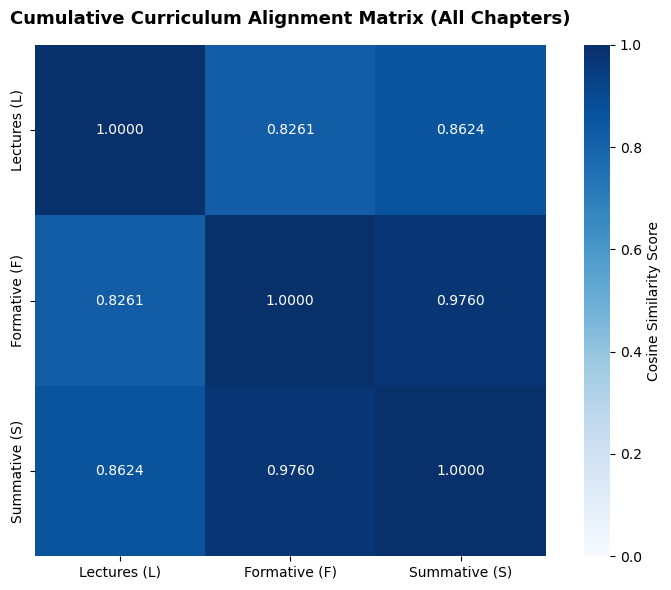

In [123]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load data
csv_data = """Chapter,L,F,S
Chapter 1,3.5,22,8
Chapter 2,4.5,12,5
Chapter 3,3.0,6,3
Chapter 4,5.0,7,2
Chapter 5,2.0,3,1
Chapter 6,4.0,5,4"""

df = pd.read_csv(io.StringIO(csv_data))

# 2. Extract vectors for the full course (across all 6 chapters)
L = df["L"].values
F = df["F"].values
S = df["S"].values

# 3. Helper function for cosine similarity calculation
def cosine_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    magnitude = np.linalg.norm(v1) * np.linalg.norm(v2)
    return dot_product / magnitude if magnitude > 0 else 0.0

# 4. Compute overall individual pair metrics
sim_LF = cosine_similarity(L, F)
sim_LS = cosine_similarity(L, S)
sim_FS = cosine_similarity(F, S)

print("=== Overall Course Cosine Similarity Metrics ===")
print(f"Lectures vs Formative (L · F): {sim_LF:.4f}")
print(f"Lectures vs Summative (L · S): {sim_LS:.4f}")
print(f"Formative vs Summative (F · S): {sim_FS:.4f}\n")

# 5. Build Cumulative Alignment Matrix DataFrame
matrix_labels = ["Lectures (L)", "Formative (F)", "Summative (S)"]
alignment_matrix = np.array([
    [1.0,    sim_LF, sim_LS],
    [sim_LF, 1.0,    sim_FS],
    [sim_LS, sim_FS, 1.0]
])

matrix_df = pd.DataFrame(alignment_matrix, columns=matrix_labels, index=matrix_labels)
print("=== Cumulative Alignment Matrix ===")
print(matrix_df)

# 6. Plot the Alignment Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix_df, 
    annot=True, 
    cmap="Blues", 
    vmin=0, 
    vmax=1, 
    fmt=".4f", 
    square=True,
    cbar_kws={'label': 'Cosine Similarity Score'}
)
plt.title("Cumulative Curriculum Alignment Matrix (All Chapters)", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()

# Save locally if needed: plt.savefig(r"...", bbox_inches='tight')
plt.show()


# Formative Analysis Code (Sievert FA25)

In [ ]:
import re
import glob

hw_files = ["HW0.tex", "HW1.tex", "HW2.tex", "HW3.tex", "HW4.tex", "HW5.tex", "HW6.tex"]

for hw in hw_files:
    try:
        with open(hw, "r") as f:
            content = f.read()
            # Look for common problem indicators in LaTeX
            print(f"\n--- {hw} ---")
            # Let's just print lines containing "Problem" or "Question"
            lines = content.split('\n')
            problem_lines = [line.strip() for line in lines if "Problem" in line or "problem" in line][:10]
            print("Sample problem lines:", problem_lines)
            
            # Count itemize items if they are used as problems?
            # Let's look for \section*{ or \subsection*{ or \begin{problem}
            sections = [line.strip() for line in lines if r"\section" in line or r"\subsection" in line][:10]
            print("Sample section lines:", sections)
    except Exception as e:
        print(f"Error reading {hw}: {e}")

In [ ]:
import PyPDF2
import re

pdf_path = "Textbook_ToC_2.pdf"
chapters = {}
try:
    with open(pdf_path, "rb") as f:
        reader = PyPDF2.PdfReader(f)
        toc_text = ""
        for i in range(len(reader.pages)):
            toc_text += reader.pages[i].extract_text() + "\n"
        
        # Extract Chapter lines
        chapter_lines = re.findall(r'CHAPTER\s+\d+.*', toc_text, re.IGNORECASE)
        for line in chapter_lines:
            print(line)
except Exception as e:
    print(f"Error reading PDF: {e}")

In [ ]:
with open("HW5.tex", "r") as f:
    content = f.read()
    sections = [line.strip() for line in content.split('\n') if r"\section" in line]
    print(sections)

In [ ]:
import pandas as pd

data = [
    ["Background / Review", 5],
    ["Chapter 1 Stern-Gerlach Experiments", 6],
    ["Chapter 2 Rotation of Basis States and Matrix Mechanics", 5],
    ["Chapter 3 Angular Momentum", 5],
    ["Chapter 4 Time Evolution", 7],
    ["Chapter 5 A System of Two Spin-1/2 Particles", 4], # Including the essay as a homework problem for this unit
    ["Chapter 6 Wave Mechanics in One Dimension", 3]
]

df = pd.DataFrame(data, columns=["chapter", "count"])
df.to_csv("Formative_counts_for_chapters_Sievert_FA25.csv", index=False)
print("done")

In [ ]:
import re
import pandas as pd
import glob

hw_files = ["HW0.tex", "HW1.tex", "HW2.tex", "HW3.tex", "HW4.tex", "HW5.tex", "HW6.tex"]

# Chapter names from the PDF
chapter_names = {
    "0": "Background / Review",
    "1": "Chapter 1 Stern-Gerlach Experiments",
    "2": "Chapter 2 Rotation of Basis States and Matrix Mechanics",
    "3": "Chapter 3 Angular Momentum",
    "4": "Chapter 4 Time Evolution",
    "5": "Chapter 5 A System of Two Spin-1/2 Particles",
    "6": "Chapter 6 Wave Mechanics in One Dimension"
}

counts = {ch: 0 for ch in chapter_names.values()}

for hw in hw_files:
    with open(hw, "r") as f:
        content = f.read()
        # Find all sections that are problems or essays
        sections = re.findall(r'\\section\*\{(Problem|Essay).*?\}', content)
        
        if "HW0" in hw:
            counts[chapter_names["0"]] += len(sections)
        elif "HW1" in hw:
            counts[chapter_names["1"]] += len(sections)
        elif "HW2" in hw:
            counts[chapter_names["2"]] += len(sections)
        elif "HW3" in hw:
            counts[chapter_names["3"]] += len(sections)
        elif "HW4" in hw:
            counts[chapter_names["4"]] += len(sections)
        elif "HW5" in hw:
            counts[chapter_names["5"]] += len(sections)
        elif "HW6" in hw:
            counts[chapter_names["6"]] += len(sections)

df = pd.DataFrame(list(counts.items()), columns=["chapter", "count"])
df.to_csv("Formative_counts_for_chapters_Sievert_FA25.csv", index=False)
print(df)

# Output

Here is the breakdown of the exam problem counts per chapter:

Background / Review: 0 problems

Chapter 1 Stern-Gerlach Experiments: 1 problem (Midterm P6 on quantum state vectors and probability)

Chapter 2 Rotation of Basis States and Matrix Mechanics: 4 problems (Midterm P3, P4, P5 on projection operators and changing representations; Final P6 on Hermitian/unitary matrices)

Chapter 3 Angular Momentum: 5 problems (Midterm P1, P2, P7, P8 on angular momentum matrices, uncertainty, and commutators; Final P5 on spin ladder commutators)

Chapter 4 Time Evolution: 1 problem (Final P4 on time evolution of three energy eigenstates)

Chapter 5 A System of Two Spin-1/2 Particles: 1 problem (Final P7 on product states and total spin)

Chapter 6 Wave Mechanics in One Dimension: 4 problems (Final P1, P2, P3, P8 on continuous wave functions, Gaussian integrals, piecewise potentials, and continuous commutators)

# Summative Analysis Code (Sievert FA25)

# AI Prepared Data from LaTeX Content  

In [86]:
#Sample workflow 

import pandas as pd
import matplotlib.pyplot as plt
 
# 1. Load the data
# Replace 'your_file.csv' with your actual filename
# df = pd.read_csv('your_file.csv')
df = pd.read_csv(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\Sievert_FA25_for_AI\Course_Assessment_Counts_Sievert_FA25.csv")

# 2. Analyze the data
print("--- Statistical Summary ---")
print(df.describe())  # Shows mean, min, max, etc.

# Example: Calculate the mean of a specific column
# average_val = df['Column_Name'].mean()
# average_val = df['L'].mean()
# print(average_val)

# #Normalization (all)

# totL = df['Lectures'].sum()
# totF = df['Formative'].sum()
# totS = df['Summative'].sum() 

# print("total: {} Lectures, {} Formative, {} Summative".format(totL, totF, totS))


#Normalization (selected rows)

totL = df['Lectures'].iloc[1:6].sum()
totF = df['Formative'].iloc[1:6].sum()
totS = df['Summative'].iloc[1:6].sum() 

print("total: {} Lectures, {} Formative, {} Summative".format(totL, totF, totS))




# #Dot products: cosine alignment (all rows)

# L = df['L'] #Lecture
# LdotL = L * L
# totLdotL = LdotL.sum()
# print("Lectures/Lectures = {}, total Lectures/Lectures = {}".format(LdotL, totLdotL))

# F = df['F'] #Formative
# FdotF = F * F
# totFdotF = FdotF.sum()
# print("Formative/Formative = {}, total Formative/Formative = {}".format(FdotF, totFdotF))

# S = df['S'] #Summative
# SdotS = S * S
# totSdotS = SdotS.sum()
# print("Summative/Summative = {}, total Summative/Summative = {}".format(SdotS, totSdotS))


#Dot products: cosine alignment (selected rows)

# L = df['L'] #Lecture
L = df['Lectures'] / df['Lectures'].sum() #Lecture
LdotL = L * L
totLdotL = LdotL.iloc[1:6].sum()
print("Lectures/Lectures = {}, total Lectures/Lectures = {}".format(LdotL, totLdotL))

# F = df['F'] #Formative
F = df['Formative'] / df['Formative'].sum() #Formative
FdotF = F * F
totFdotF = FdotF.iloc[1:6].sum()
print("Formative/Formative = {}, total Formative/Formative = {}".format(FdotF, totFdotF))

# S = df['S'] #Summative
S = df['Summative'] / df['Summative'].sum() #Summative
SdotS = S * S
totSdotS = SdotS.iloc[1:6].sum()
print("Summative/Summative = {}, total Summative/Summative = {}".format(SdotS, totSdotS))


LdotF = L * F
LdotS = L * S
FdotS = F * S


# # Sums values in rows 1 to 6 for the LdotF column (selected rows)

# totLdotF = LdotF.sum()
# totLdotS = LdotS.sum()
# totFdotS = FdotS.sum()


# Sums values in rows 1 to 6 for the LdotF column (selected rows)

totLdotF = LdotF.iloc[1:6].sum()
totLdotS = LdotS.iloc[1:6].sum()
totFdotS = FdotS.iloc[1:6].sum()



print("Lectures/Formative = {}, total Lectures/Formative = {}".format(LdotF, totLdotF))
print("Lectures/Summative = {}, total Lectures/Summative = {}".format(LdotS, totLdotS))
print("Formative/Summative = {}, total Formative/Summative = {}".format(FdotS, totFdotS))

# print("total: Lectures/Formative = {}, Lectures/Summative = {}, Formative/Summative = {}".format(totLdotF, totLdotS, totFdotS))


totalignLdotF = totLdotF / np.sqrt(totLdotL * totFdotF)
totalignLdotS = totLdotS / np.sqrt(totLdotL * totSdotS)
totalignFdotS = totFdotS / np.sqrt(totFdotF * totSdotS)

print("total alignment: Lectures/Formative = {}, Lectures/Summative = {}, Formative/Summative = {}".format(totalignLdotF, totalignLdotS, totalignFdotS))



--- Statistical Summary ---
       Lectures  Formative  Summative
count  8.000000    8.00000   8.000000
mean   3.125000    4.37500   4.750000
std    2.232071    2.99261   4.140393
min    0.000000    0.00000   0.000000
25%    1.500000    2.71250   2.250000
50%    4.000000    4.00000   3.750000
75%    4.250000    6.08750   7.375000
max    6.000000    8.70000  11.000000
total: 21 Lectures, 27.0 Formative, 27.0 Summative
Lectures/Lectures = 0    0.0000
1    0.0256
2    0.0576
3    0.0256
4    0.0400
5    0.0064
6    0.0256
7    0.0000
Name: Lectures, dtype: float64, total Lectures/Lectures = 0.15519999999999998
Formative/Formative = 0    0.020408
1    0.002794
2    0.061788
3    0.024247
4    0.052245
5    0.007347
6    0.007347
7    0.000000
Name: Formative, dtype: float64, total Formative/Formative = 0.1484204081632653
Summative/Summative = 0    0.000000
1    0.008483
2    0.069252
3    0.029259
4    0.006233
5    0.011080
6    0.083795
7    0.000000
Name: Summative, dtype: float64, tota

In [ ]:
#Plot data from Excel (.csv) file
#Sievert_2024 

# # 3. Plot the data
# plt.figure(figsize=(10, 6))

# # Example: A simple line plot
# # Replace 'X_Axis_Column' and 'Y_Axis_Column' with your actual headers
# plt.plot(df['X_Axis_Column'], df['Y_Axis_Column'], marker='o', linestyle='-', color='b', label='Data Trend')

# # Customizing the chart
# plt.title('Data Analysis Results')
# plt.xlabel('X-Axis Label')
# plt.ylabel('Y-Axis Label')
# plt.legend()
# plt.grid(True)

# # Display the plot
# plt.show()


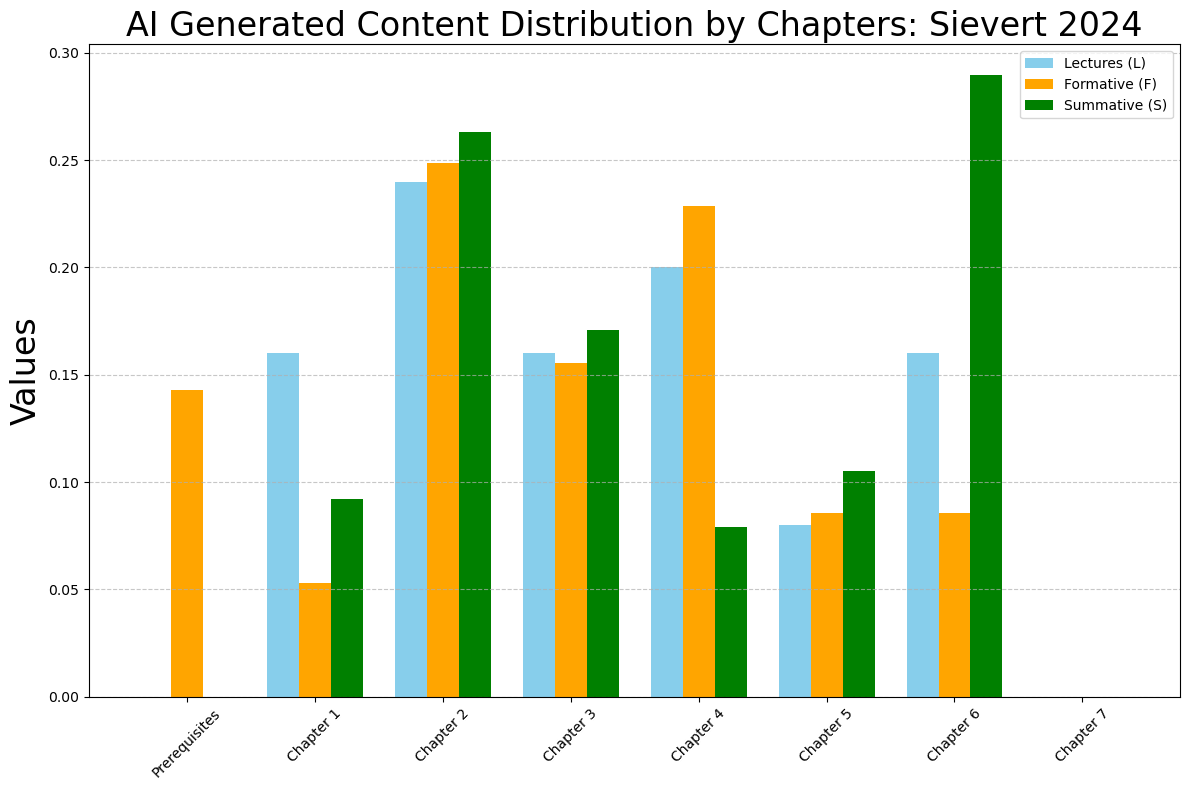

In [30]:
# Option 1: Plotting ALL Chapters

import matplotlib.pyplot as plt
import numpy as np

# 1. Setup data (all data)
chapters = df['Chapter'] 
x = np.arange(len(chapters))  # Fixed capitalization
width = 0.25 

# 2. Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Use full df to match x
rects1 = ax.bar(x - width, L, width, label='Lectures (L)', color='skyblue')
rects2 = ax.bar(x, F, width, label='Formative (F)', color='orange')
rects3 = ax.bar(x + width, S, width, label='Summative (S)', color='green')

# 3. Add labels and formatting
ax.set_ylabel('Values', fontsize=24)
ax.set_title('AI Generated PHYS 454 Content Distribution by Chapters: Sievert (Fall 2025)', fontsize=24)
ax.set_xticks(x)
ax.set_xticklabels(chapters, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
# plt.savefig(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\AI_content_dist_by_chapters_Sievert_2025_all.png", bbox_inches='tight')
plt.show()


total alignment: Lectures/Formative = 0.9593315017701382, Lectures/Summative = 0.9321526055467356, Formative/Summative = 0.9127956758396476


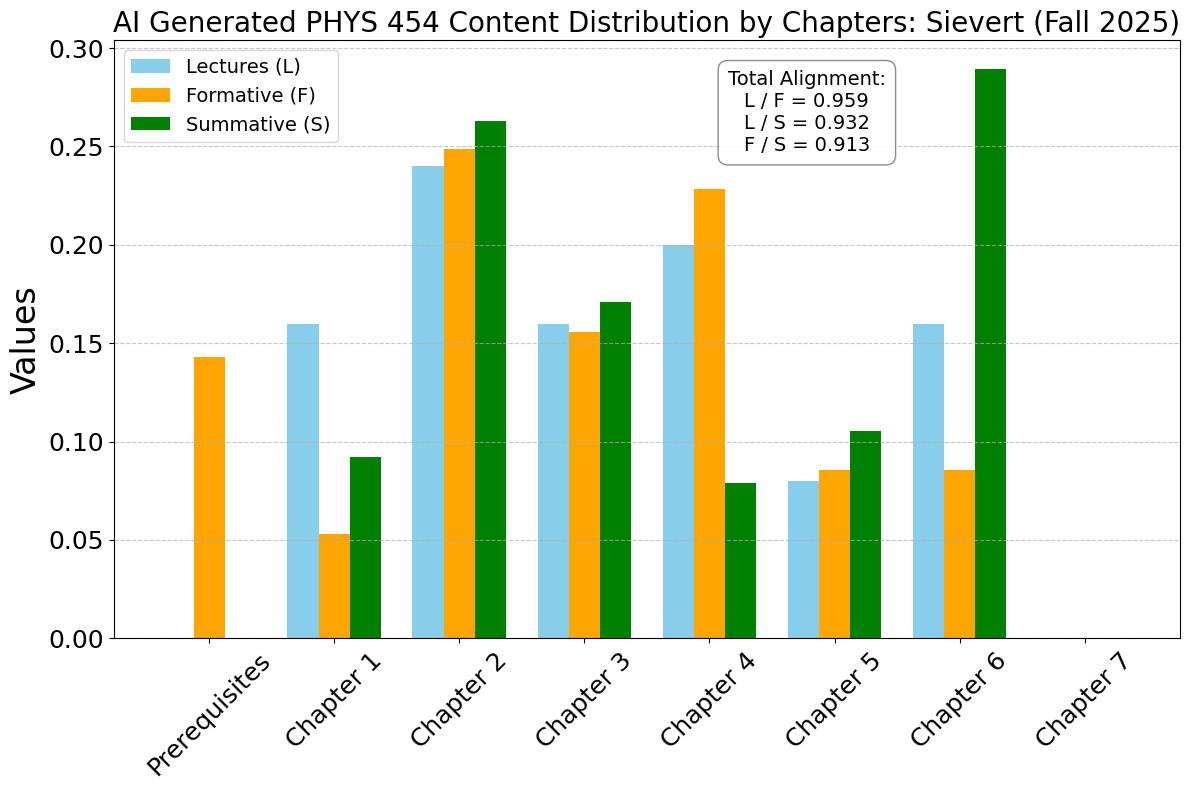

In [110]:
# Same as above plot with added alignment textbox 

import matplotlib.pyplot as plt
import numpy as np

# --- MATH CALCULATIONS ---
# (Ensure these dot product variables are computed from your data before this script runs)
totalignLdotF = totLdotF / np.sqrt(totLdotL * totFdotF)
totalignLdotS = totLdotS / np.sqrt(totLdotL * totSdotS)
totalignFdotS = totFdotS / np.sqrt(totFdotF * totSdotS)

print("total alignment: Lectures/Formative = {}, Lectures/Summative = {}, Formative/Summative = {}".format(totalignLdotF, totalignLdotS, totalignFdotS))

# --- PLOTTING CODE ---
# Option 1: Plotting ALL Chapters

# 1. Setup data (all data)
chapters = df['Chapter'] 
x = np.arange(len(chapters))  
width = 0.25 

# 2. Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Use full df columns to match x
rects1 = ax.bar(x - width, L, width, label='Lectures (L)', color='skyblue')
rects2 = ax.bar(x,         F, width, label='Formative (F)', color='orange')
rects3 = ax.bar(x + width, S, width, label='Summative (S)', color='green')

# 3. Add labels and formatting
ax.set_ylabel('Values', fontsize=24)
ax.set_title('AI Generated PHYS 454 Content Distribution by Chapters: Sievert (Fall 2025)', fontsize=20)

# --- INCREASED TICK FONT SIZES ---
ax.set_xticks(x)
ax.set_xticklabels(chapters, rotation=45, fontsize=18) # Increased x-ticks to 18
ax.tick_params(axis='y', labelsize=18)                  # Increased y-ticks to 18

ax.legend(loc='upper left', fontsize=14)  # Left-aligned to make space for the right math box

# --- ADDED: MATHEMATICAL ALIGNMENT TEXT BOX ---
alignment_text = (
    f"Total Alignment:\n"
    f"L / F = {totalignLdotF:.3f}\n"
    f"L / S = {totalignLdotS:.3f}\n"
    f"F / S = {totalignFdotS:.3f}"
)

# Shifted x position to 0.65 and changed horizontalalignment to 'center'
ax.text(
    0.65, 0.95, alignment_text, 
    transform=ax.transAxes, 
    fontsize=14,
    verticalalignment='top', 
    horizontalalignment='center',  # Centers text inside the box safely
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
)

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# plt.savefig(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\AI_content_dist_by_chapters_Sievert_2025_all.png", bbox_inches='tight')
plt.show()


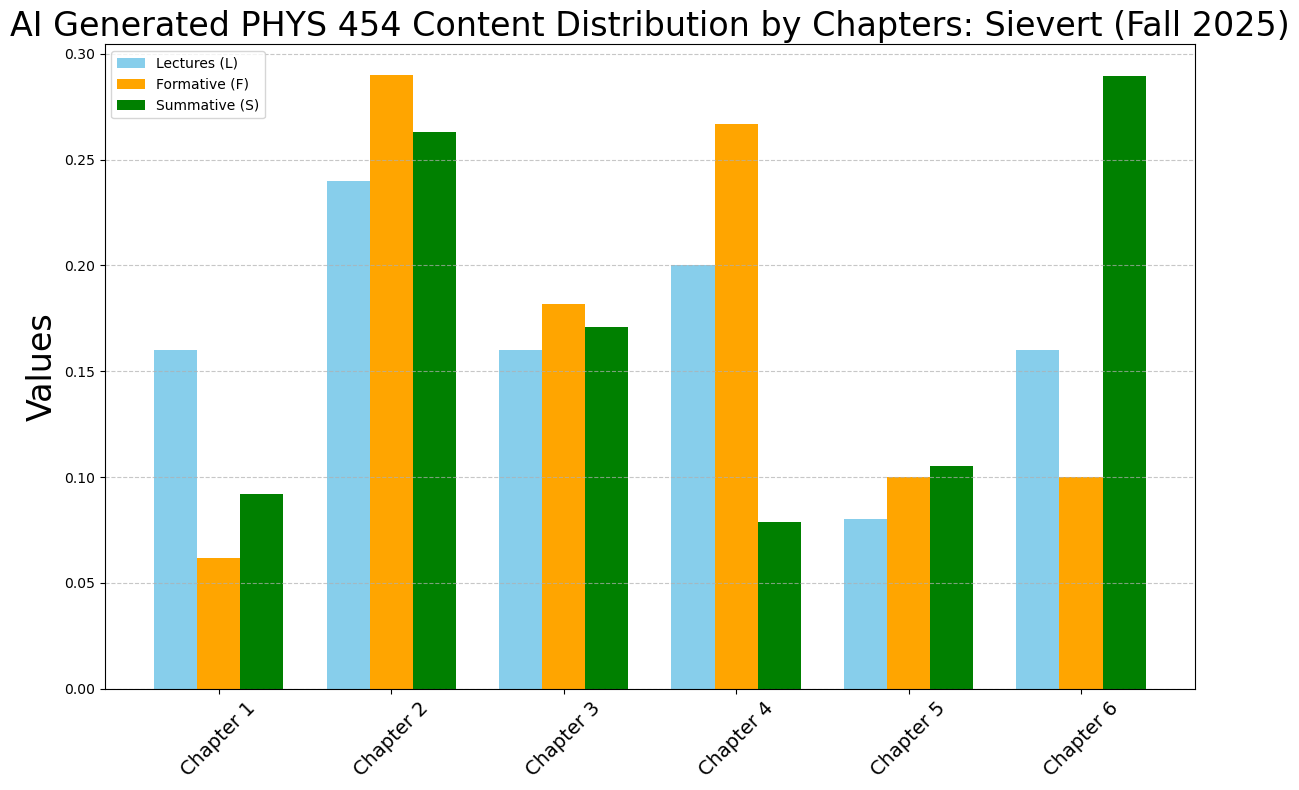

In [123]:
# Option 2: Plotting a SUBSET (Chapters 1 to 6)

import matplotlib.pyplot as plt
import numpy as np

# 1. Slice your data to match your analysis (Rows 1 to 6)
subset_df = df.iloc[1:7] 
chapters = subset_df['Chapter'] # Ensure this matches your column name
x = np.arange(len(chapters)) 
width = 0.25 

# 2. Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Use subset_df here instead of df to keep lengths equal
rects1 = ax.bar(x - width, subset_df['Lectures']/subset_df['Lectures'].sum(), width, label='Lectures (L)', color='skyblue')
rects2 = ax.bar(x, subset_df['Formative']/subset_df['Formative'].sum(), width, label='Formative (F)', color='orange')
rects3 = ax.bar(x + width, subset_df['Summative']/subset_df['Summative'].sum(), width, label='Summative (S)', color='green')

# 3. Add labels and formatting
ax.set_ylabel('Values', fontsize=24)
ax.set_title('AI Generated PHYS 454 Content Distribution by Chapters: Sievert (Fall 2025)', fontsize=24)
ax.set_xticks(x)
ax.set_xticklabels(chapters, rotation=45, fontsize=14)
ax.legend() #fontsize=18
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
# plt.savefig(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\AI_content_dist_by_chapters_Sievert_2025_ch1to6.png", bbox_inches='tight')
plt.show()



total alignment: Lectures/Formative = 0.9593315017701382, Lectures/Summative = 0.9321526055467356, Formative/Summative = 0.9127956758396476


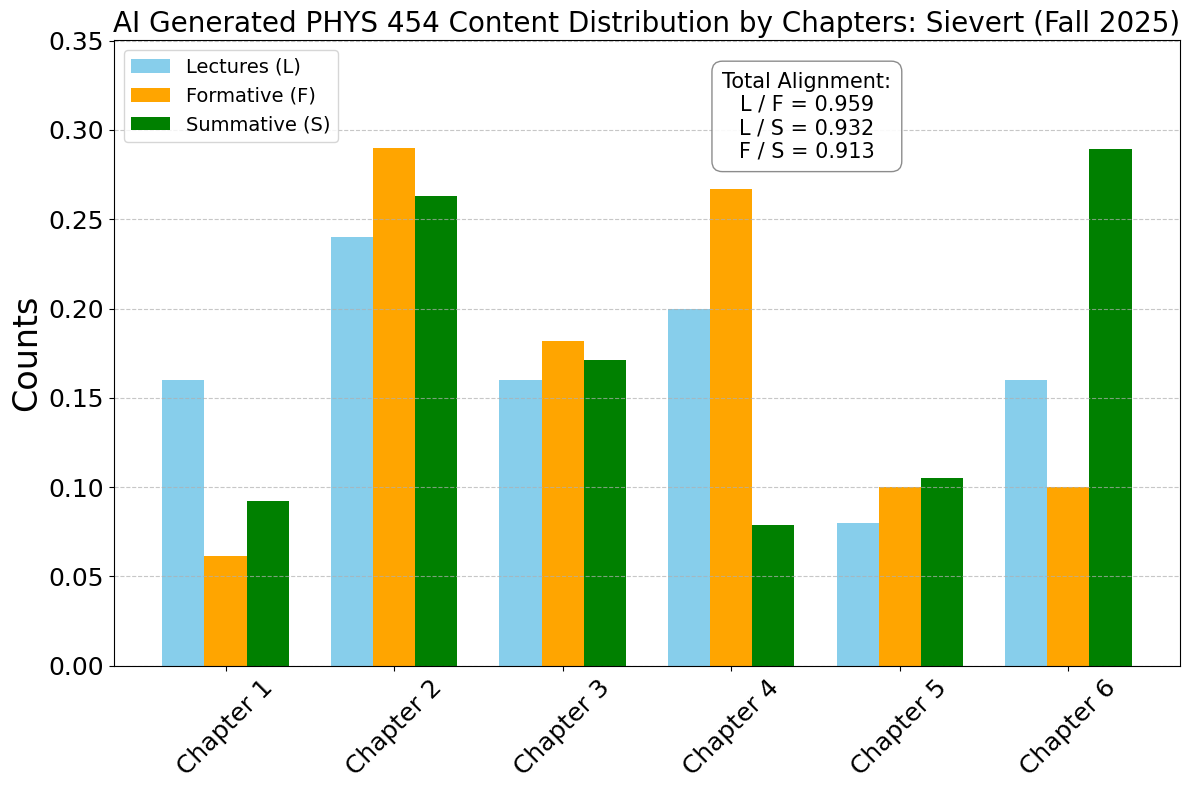

In [125]:
#Same as above plot with added textbox of alignment of vectors

import matplotlib.pyplot as plt
import numpy as np

# --- MATH CALCULATIONS ---
totalignLdotF = totLdotF / np.sqrt(totLdotL * totFdotF)
totalignLdotS = totLdotS / np.sqrt(totLdotL * totSdotS)
totalignFdotS = totFdotS / np.sqrt(totFdotF * totSdotS)

print("total alignment: Lectures/Formative = {}, Lectures/Summative = {}, Formative/Summative = {}".format(totalignLdotF, totalignLdotS, totalignFdotS))

# --- PLOTTING CODE ---
# Option 2: Plotting a SUBSET (Chapters 1 to 6)

# 1. Slice your data to match your analysis (Rows 1 to 6)
subset_df = df.iloc[1:7] 
chapters = subset_df['Chapter'] 
x = np.arange(len(chapters)) 
width = 0.25 

# 2. Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Use subset_df here instead of df to keep lengths equal
rects1 = ax.bar(x - width, subset_df['Lectures']/subset_df['Lectures'].sum(), width, label='Lectures (L)', color='skyblue')
rects2 = ax.bar(x,         subset_df['Formative']/subset_df['Formative'].sum(), width, label='Formative (F)', color='orange')
rects3 = ax.bar(x + width, subset_df['Summative']/subset_df['Summative'].sum(), width, label='Summative (S)', color='green')

# 3. Add labels and formatting
ax.set_ylabel('Counts', fontsize=24)
ax.set_title('AI Generated PHYS 454 Content Distribution by Chapters: Sievert (Fall 2025)', fontsize=20)
# --- INCREASED TICK FONT SIZES ---
ax.set_xticks(x)
ax.set_xticklabels(chapters, rotation=45, fontsize=18) # Increased x-ticks to 18
ax.tick_params(axis='y', labelsize=18)                  # Increased y-ticks to 18

ax.legend(loc='upper left', fontsize=14)  # Left-aligned to make space for the right math box

# --- ADJUSTED POSITION TO PREVENT OVERFLOW ---
alignment_text = (
    f"Total Alignment:\n"
    f"L / F = {totalignLdotF:.3f}\n"
    f"L / S = {totalignLdotS:.3f}\n"
    f"F / S = {totalignFdotS:.3f}"
)

# Centered at 0.65 x-axis to prevent running off the right edge
ax.text(
    0.65, 0.95, alignment_text, 
    transform=ax.transAxes, 
    fontsize=15,
    verticalalignment='top', 
    horizontalalignment='center',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
)

ax.grid(axis='y', linestyle='--', alpha=0.7)

# Expand the vertical headroom by 15% so the text box does not overlap any tall bars
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
# plt.savefig(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\AI_content_dist_by_chapters_Sievert_2025_ch1to6.png", bbox_inches='tight')
plt.show()


In [38]:
# #Plot B: Course Alignment by Chapter: Sievert

# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# # 1. Slice the 6 chapters without pre and extra (Index 1 to 7)
# subset = df.iloc[1:7].copy()

# # 2. Calculate the dot products per chapter
# subset['LdotF'] = subset['L'] * subset['F']
# subset['LdotS'] = subset['L'] * subset['S']
# subset['FdotS'] = subset['F'] * subset['S']

# # 3. Setup the plot positions
# x = np.arange(len(subset))  # Length is 6
# width = 0.25 

# fig, ax = plt.subplots(figsize=(12, 8))

# # 4. Plot the 3 dot product categories
# rects1 = ax.bar(x - width, subset['LdotF'], width, label='L · F (Lecture/Formative)', color='#9b59b6') # Purple
# rects2 = ax.bar(x,         subset['LdotS'], width, label='L · S (Lecture/Summative)', color='#3498db') # Blue
# rects3 = ax.bar(x + width, subset['FdotS'], width, label='F · S (Formative/Summative)', color='#e67e22') # Orange

# # 5. Formatting
# # ax.set_xlabel('Chapters')
# ax.set_ylabel('Alignment Value', fontsize=24)
# ax.set_title('Course Alignment by Chapters: Sievert 2024', fontsize=26)
# ax.set_xticks(x)
# ax.set_xticklabels(subset['name'], rotation=45)
# ax.legend(fontsize=16)
# ax.grid(axis='y', linestyle='--', alpha=0.6)

# plt.tight_layout()

# # Save the plot (using double quotes for the path with an apostrophe)
# # save_path = r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\course_alignment_by_chapters_Sievert_2024_ch1to6.png.png"
# plt.savefig(save_path, bbox_inches='tight')

# plt.show()


# Merging Human-prepared and AI-prepared (.csv) data

In [53]:
import pandas as pd

df1 = pd.read_csv(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\Sievert_FA25_for_AI\Alignment_Chapters_Sievert_cleaned_minimal.csv") #human-labeled data
df2 = pd.read_csv(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\Sievert_FA25_for_AI\Course_Assessment_Counts_Sievert_FA25.csv") #AI-labeled data

# Merges only on rows where the 'ID' matches in both
merged_df = pd.merge(df1, df2, on='Lectures', suffixes=('_file1', '_file2'))
print(merged_df)

                         Chapter_file1  Lectures  Formative_file1  \
0                Ch3 Angular Momentum        5.0                5   
1                  Ch4 Time Evolution        5.0                7   
2  Ch5 System of 2 Spin-1/2 Particles        2.0                3   
3            Ch6 Wave Mechanics in 1D        4.0                3   
4            Ch6 Wave Mechanics in 1D        4.0                3   
5            Ch6 Wave Mechanics in 1D        4.0                3   

   Summative_file1 Chapter_file2  Formative_file2  Summative_file2  
0             5.66     Chapter 4             8.00              3.0  
1             3.00     Chapter 4             8.00              3.0  
2             1.20     Chapter 5             3.00              4.0  
3             6.83     Chapter 1             1.85              3.5  
4             6.83     Chapter 3             5.45              6.5  
5             6.83     Chapter 6             3.00             11.0  


C:\Users\Hasan's PC\AppData\Local\Temp\ipykernel_22428\247035876.py:7: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  merged_df = pd.merge(df1, df2, on='Lectures', suffixes=('_file1', '_file2'))


In [59]:
# Calculate directional percentage difference
# merged_df['pct_diff'] = ((merged_df['value_file2'] - merged_df['value_file1']) / merged_df['value_file1']) * 100

merged_df['pct_diff_F'] = ((merged_df['Formative_file2'] - merged_df['Formative_file1']) / merged_df['Formative_file1']) * 100

merged_df['pct_diff_S'] = ((merged_df['Summative_file2'] - merged_df['Summative_file1']) / merged_df['Summative_file1']) * 100

print(merged_df['pct_diff_F'])
print(merged_df['pct_diff_S'])


0    60.000000
1    14.285714
2     0.000000
3   -38.333333
4    81.666667
5     0.000000
Name: pct_diff_F, dtype: float64
0    -46.996466
1      0.000000
2    233.333333
3    -48.755490
4     -4.831625
5     61.054173
Name: pct_diff_S, dtype: float64


# Cosine alignment tests on 2 CSV files

✅ Position matching successful! Plotted items: ['Ch1: Stern-Gerlach Experiments ', 'Ch2: Rotation of Basis States / Matrix Mechanics ', 'Ch3: Angular Momentum ', 'Ch4: Time Evolution ', 'Ch5: System of 2 Spin-1/2 Particles ', 'Ch6: Wave Mechanics in 1D ']
Human/AI Alignment: Lectures=0.993, Formative=0.912, Summative=0.864


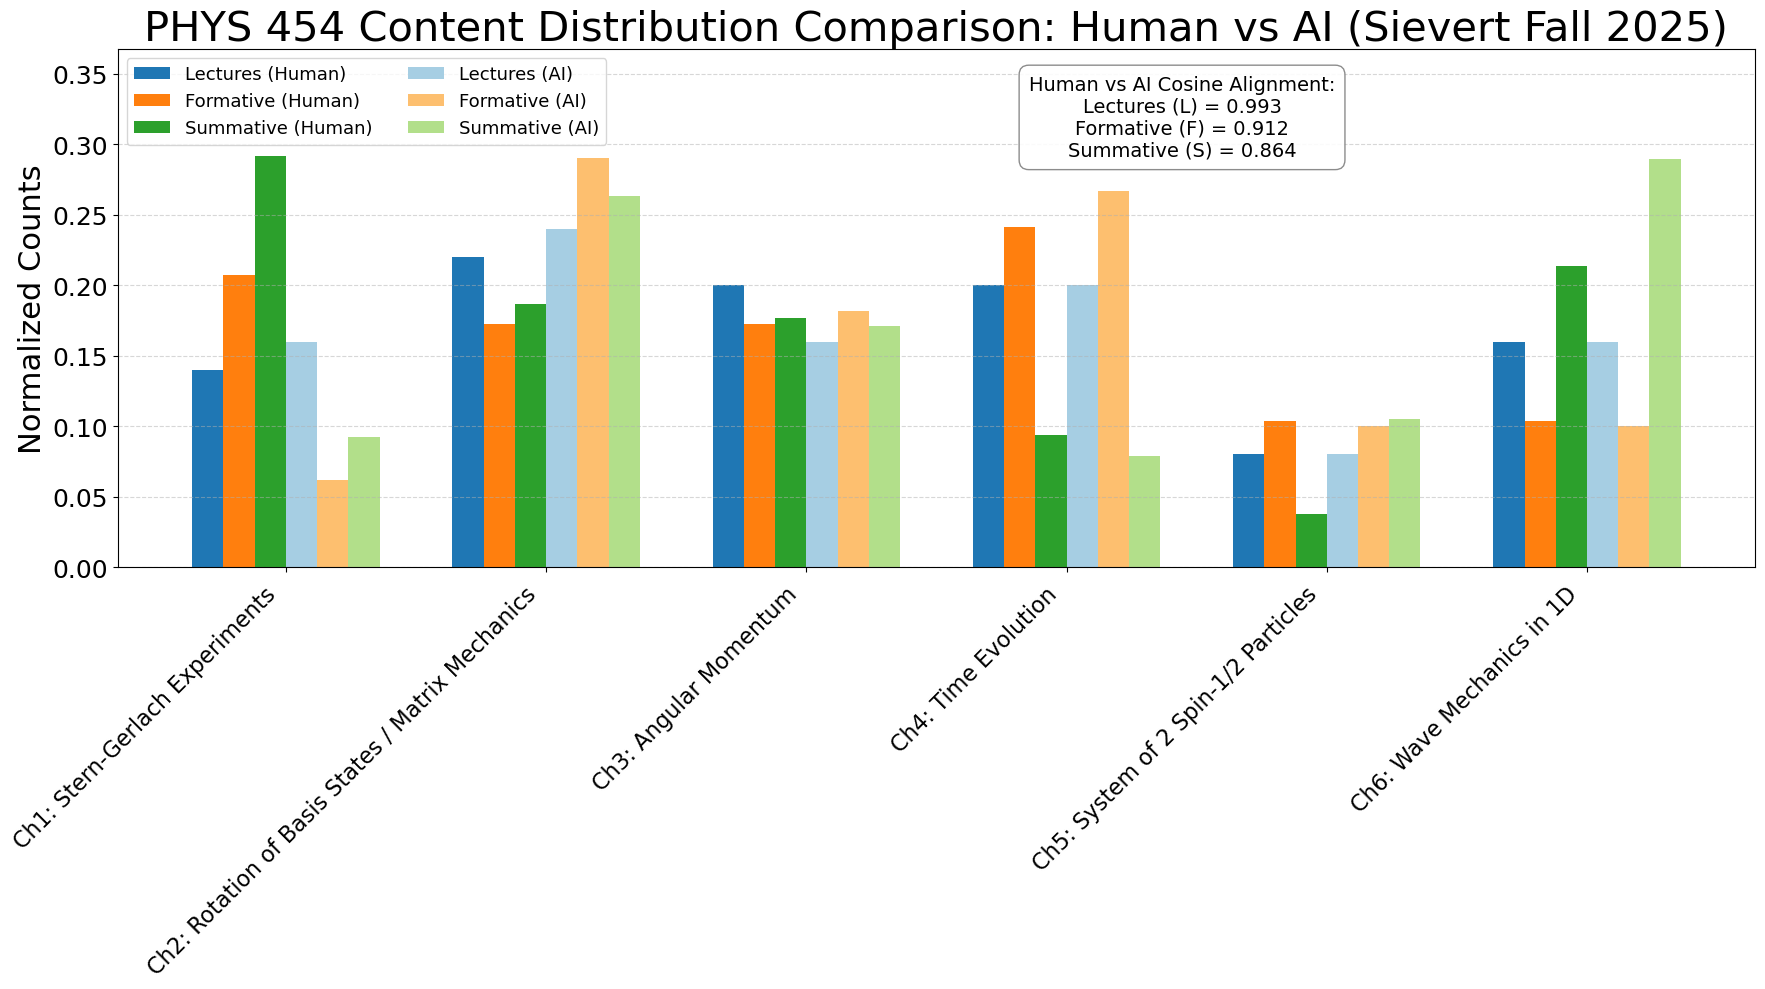

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =====================================================================
# 1. LOAD DATASETS
# =====================================================================
df1 = pd.read_csv(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\Sievert_FA25_for_AI\Alignment_Chapters_Sievert_cleaned_minimal.csv") # Human
df2 = pd.read_csv(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\Sievert_FA25_for_AI\Course_Assessment_Counts_Sievert_FA25.csv")     # AI

# Automatically strip tracking spaces from columns
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

# Standardize data column names to short variables ('L', 'F', 'S')
rename_dict = {'Lectures': 'L', 'Formative': 'F', 'Summative': 'S'}
df1 = df1.rename(columns=rename_dict)
df2 = df2.rename(columns=rename_dict)

# =====================================================================
# 2. POSITION SPLICING (Grabs actual data rows directly, ignores text names)
# =====================================================================
# We will pull rows 1 to 6 (Chapters 1-6) using index slices to bypass string-matching bugs
subset_human = df1.iloc[1:7]
subset_ai    = df2.iloc[1:7]

# Find the label column dynamically (checks 'Chapter', 'name', 'LO', etc.)
label_col_h = [col for col in df1.columns if col in ['Chapter', 'name', 'LO']][0]
label_col_a = [col for col in df2.columns if col in ['Chapter', 'name', 'LO']][0]

labels = subset_human[label_col_h].astype(str).values
x = np.arange(len(labels))
width = 0.12

# =====================================================================
# 3. VECTOR COSINE ALIGNMENT CALCULATIONS
# =====================================================================
L_h, L_a = subset_human["L"].values, subset_ai["L"].values
F_h, F_a = subset_human["F"].values, subset_ai["F"].values
S_h, S_a = subset_human["S"].values, subset_ai["S"].values

def cosine_alignment(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm1 = np.sqrt(np.dot(vec1, vec1))
    norm2 = np.sqrt(np.dot(vec2, vec2))
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return dot_product / (norm1 * norm2)

align_L = cosine_alignment(L_h, L_a)
align_F = cosine_alignment(F_h, F_a)
align_S = cosine_alignment(S_h, S_a)

print(f"✅ Position matching successful! Plotted items: {list(labels)}")
print(f"Human/AI Alignment: Lectures={align_L:.3f}, Formative={align_F:.3f}, Summative={align_S:.3f}")

# =====================================================================
# 4. PLOTTING CODE
# =====================================================================
fig, ax = plt.subplots(figsize=(18, 10))

# Plot HUMAN Proportions
ax.bar(x - 2.5 * width, L_h / L_h.sum(), width, label="Lectures (Human)", color="#1f77b4")
ax.bar(x - 1.5 * width, F_h / F_h.sum(), width, label="Formative (Human)", color="#ff7f0e")
ax.bar(x - 0.5 * width, S_h / S_h.sum(), width, label="Summative (Human)", color="#2ca02c")

# Plot AI Proportions
ax.bar(x + 0.5 * width, L_a / L_a.sum(), width, label="Lectures (AI)",    color="#a6cee3")
ax.bar(x + 1.5 * width, F_a / F_a.sum(), width, label="Formative (AI)",   color="#fdbf6f")
ax.bar(x + 2.5 * width, S_a / S_a.sum(), width, label="Summative (AI)",   color="#b2df8a")

# Axis Labels

ax.set_ylabel("Normalized Counts", fontsize=22)
ax.set_title("PHYS 454 Content Distribution Comparison: Human vs AI (Sievert Fall 2025)", fontsize=30)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, fontsize=16, ha="right")
ax.tick_params(axis="y", labelsize=18)
ax.legend(loc="upper left", fontsize=13, ncol=2)

# Legend TextBox
alignment_text = (
    f"Human vs AI Cosine Alignment:\n"
    f"Lectures (L) = {align_L:.3f}\n"
    f"Formative (F) = {align_F:.3f}\n"
    f"Summative (S) = {align_S:.3f}"
)

ax.text(
    0.65, 0.95, alignment_text, 
    transform=ax.transAxes, 
    fontsize=14,
    verticalalignment="top", 
    horizontalalignment="center",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9)
)

ax.grid(axis="y", linestyle="--", alpha=0.5)

# FIXED: Extract tuple ceiling cleanly using index [1]
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

plt.tight_layout()
plt.savefig(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\Human_vs_AI_chapter_alignment_Sievert_2025_v2.png", bbox_inches='tight')
plt.show()
